In [1]:
import numpy as np
import emcee
import corner
from astropy.io import fits
from astropy import units as u
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from cmcrameri import cm
import pandas as pd
from astropy.coordinates import SkyCoord
from PIL import Image
from cmcrameri import cm
import scipy
from mpl_toolkits.axes_grid1 import make_axes_locatable
from numpy import linalg
from dynesty import plotting as dyplot
from dynesty.results import Results
# seed the random number generator
import dynesty

In [2]:
# 1D Gaussian for debug purposes
def gaussian(x, flux = 1.0, centre = 0.0, sigma = 1.0, background = 0.0):
    amplitude = flux / np.sqrt(2 * np.pi * sigma ** 2) 
    value = amplitude * np.exp(-0.5 * (x - centre)**2 / sigma**2) + background
    return value

# 2D Gaussian
def gaussian2D(x, y, flux, x_centre = 0.0 , y_centre = 0.0, sigma = 1.0):
    amplitude = flux / (2 * np.pi * sigma**2)
    value = amplitude * np.exp(-0.5 * ((x - x_centre)**2 + (y - y_centre)**2) / sigma**2)
    return value

# 2D Gaussian with constant background
def gaussian2D_bkg_constant(x, y, flux, x_centre = 0.0 , y_centre = 0.0, sigma = 1.0, background_b = 0.0):
    amplitude = flux / (2 * np.pi * sigma**2)
    value = amplitude * np.exp(-0.5 * ((x - x_centre)**2 + (y - y_centre)**2) / sigma**2) + background_b
    return value

# 2D Gaussian with background gradient in Y direction
def gaussian2D_gradY(x, y, flux, x_centre = 0.0 , y_centre = 0.0, sigma = 1.0, background_a = 0.0, background_b = 0.0):
    amplitude = flux / (2 * np.pi * sigma**2)
    value = amplitude * np.exp(-0.5 * ((x - x_centre)**2 + (y - y_centre)**2) / sigma**2) + background_a * y + background_b
    return value

# 2D Gaussian with background gradient in X direction
def gaussian2D_gradX(x, y, flux, x_centre = 0.0 , y_centre = 0.0, sigma = 1.0, background_a = 0.0, background_b = 0.0):
    amplitude = flux / (2 * np.pi * sigma**2)
    value = amplitude * np.exp(-0.5 * ((x - x_centre)**2 + (y - y_centre)**2) / sigma**2) + background_a * x + background_b
    return value

# 2D Gaussian with background gradient in both X and Y directions
def gaussian2D_gradXY(x, y, flux, x_centre = 0.0 , y_centre = 0.0, sigma = 1.0, background_a = 0.0, background_b = 0.0, background_c = 0.0):
    amplitude = flux / (2 * np.pi * sigma**2)
    value = amplitude * np.exp(-0.5 * ((x - x_centre)**2 + (y - y_centre)**2) / sigma**2) + background_a * x + background_b * y + background_c 
    return value

# 2D Gaussian with background gradient in both X and Y directions and rotation
def gaussian2D_gradXY_rot(x, y, flux, x_centre=0.0, y_centre=0.0, sigma_x=1.0, sigma_y=1.0, angle=0.0, background_a=0.0, background_b=0.0, background_c=0.0):
    cos_angle = np.cos(np.deg2rad(angle))
    sin_angle = np.sin(np.deg2rad(angle))
    
    x_rot = (x - x_centre) * cos_angle - (y - y_centre) * sin_angle
    y_rot = (x - x_centre) * sin_angle + (y - y_centre) * cos_angle
    
    amplitude = flux / (2 * np.pi * sigma_x * sigma_y)
    value = amplitude * np.exp(-0.5 * ((x_rot / sigma_x)**2 + (y_rot / sigma_y)**2)) + background_a * x + background_b * y + background_c 
    return value

In [3]:
def weighted_avg_and_std(values, weights):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they 
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    average = np.average(values, weights=weights)
    # Fast and numerically precise:
    variance = np.average((values-average)**2, weights=weights)
    return (average, np.sqrt(variance))


In [4]:
# FF functions
h    = 6.62607e-34 # Planck's konstant
k_b  = 1.38065e-23 # Boltzmanns konstant
Tcmb = 2.7255      # K CMB Temperature
c    = 299792458   # c light speed

def calc_EM(nu_turn,Te):
    T4 = Te*1e-4
    nu9 = nu_turn #Hz
    g_ff = np.float64(np.log(np.exp(5.960-np.sqrt(3)/np.pi*np.log(nu9*T4**(-3./2.)))+np.e))
    EM = 1 /np.float64(0.05468*Te**(-3./2.)*nu9**(-2)*g_ff)
    return EM

def calc_nu_turn(nu, EM, Te):
    T4 = Te*1e-4
    nu9 = nu #Hz
    g_ff = np.float64(np.log(np.exp(5.960-np.sqrt(3)/np.pi*np.log(nu9*T4**(-3./2.)))+np.e))
    nu_turn = (1 / np.float64(0.05468*EM*Te**(-3./2.)*g_ff))**(-1/2)
    return nu_turn

def ffEM(nu,EM,Te,fwhm):
    Omega_beam = np.pi * fwhm** 2 / (4 * np.log(2))
    T4 = Te*1e-4
    nu9 = nu*1e9 #Hz
    g_ff = np.float64(np.log(np.exp(5.960-np.sqrt(3)/np.pi*np.log(nu*T4**(-3./2.)))+np.e))
    tau = np.float64(0.05468*EM*Te**(-3./2.)*nu**(-2)*g_ff)
    t_ff = Te*(1 - np.float64(np.exp(-tau)))
    s_ff = 2*k_b*t_ff*(nu9)**2*Omega_beam  *1e26 *1e3 / c**2 # mJy
    #print('omega beam: ', Omega_beam, 'T4: ', T4, 'nu: ', nu, 'g_ff: ', g_ff, 'tau: ', tau, 't_ff: ', t_ff, 's_ff: ', s_ff)
    return s_ff


In [17]:
def calc_EM_and_nu_turn(freq, source_flux, source_dflux, Te, angular_size):
    npoints = 1
    rstate = np.random.default_rng(666)
    ndim = 1
    flux_data  = source_flux
    flux_error = source_dflux
    C = flux_error**2
    Cinv = 1/flux_error**2
    lnorm     = -0.5 * (np.log(2 * np.pi) * npoints + np.log(C))  # ln(normalization)
    label = [r'log10(EM)']

    def loglikelihood(theta):
        """Multivariate normal log-likelihood."""
        # CMB
        EM          = 10**theta[0]
        flux_theory = ffEM(freq,EM,Te,np.radians(angular_size/3600))

        logLike = -0.5 * (flux_data - flux_theory) * Cinv * (flux_data - flux_theory) + lnorm
        return logLike

    def linear_transform(prior, a, b):
        return a + prior * (b-a) 

    def truncated_normal(prior, m, s, low, high):
        low_n, high_n = (low - m) / s, (high - m) / s  # standardize
        prior = scipy.stats.truncnorm.ppf(prior, low_n, high_n, loc=m, scale=s)
        return prior

    # prior transform (iid standard normal prior)
    def prior_transform(u):
        """Transforms our unit cube samples `u` to a standard normal prior."""
        
        priors = np.array(u)
        priors[0] = linear_transform(priors[0], 0, 10) # log10EM
        return priors

    # ln(evidence)
    lnz_truth = lnorm - 0.5 * npoints * np.log(2)
    #print(lnz_truth)

    # hamiltonian slice sampling ('hslice')
    sampler = dynesty.NestedSampler(loglikelihood, prior_transform, ndim, nlive=250,
                                    sample='rwalk', rstate=rstate)
    sampler.run_nested(dlogz=0.00001)
    res = sampler.results

    EM_sol, dEM_sol = weighted_avg_and_std(np.squeeze(res.samples), np.exp(np.squeeze(res.logwt)))

    EM_data  = EM_sol
    EM_error = dEM_sol
    C = EM_error**2
    Cinv = 1/EM_error**2
    lnorm     = -0.5 * (np.log(2 * np.pi) * npoints + np.log(C))  # ln(normalization)
    label = [r'nu']

    def loglikelihood(theta):
        """Multivariate normal log-likelihood."""
        # CMB
        nu_turn   = theta[0]
        EM_theory = np.log10(calc_EM(nu_turn,Te))

        logLike = -0.5 * (EM_data - EM_theory) * Cinv * (EM_data - EM_theory) + lnorm
        return logLike

    def linear_transform(prior, a, b):
        return a + prior * (b-a) 

    def truncated_normal(prior, m, s, low, high):
        low_n, high_n = (low - m) / s, (high - m) / s  # standardize
        prior = scipy.stats.truncnorm.ppf(prior, low_n, high_n, loc=m, scale=s)
        return prior

    # prior transform (iid standard normal prior)
    def prior_transform(u):
        """Transforms our unit cube samples `u` to a standard normal prior."""
        
        priors = np.array(u)
        priors[0] = linear_transform(priors[0], 0, 10) # log10nu
        return priors

    # ln(evidence)
    lnz_truth = lnorm - 0.5 * npoints * np.log(2)
    #print(lnz_truth)

    # hamiltonian slice sampling ('hslice')
    sampler = dynesty.NestedSampler(loglikelihood, prior_transform, ndim, nlive=250,
                                    sample='rwalk', rstate=rstate)
    sampler.run_nested(dlogz=0.00001)
    res = sampler.results

    nuTurn_sol, dnuTurn_sol = weighted_avg_and_std(np.squeeze(res.samples), np.exp(np.squeeze(res.logwt)))

    return EM_sol, dEM_sol, nuTurn_sol, dnuTurn_sol

In [10]:
# Load the COMAP temperature map, the noise map and the coord. system. 
map_path = '/Users/user/phd/hoerning24_comap_science/galactic_2023-10-24/maps/All_galactic_2023-10-24_Band00.fits'
comap_27GHz_full = fits.open(map_path)
lightSpeed = 299792458 # m s-1
boltzmann_constant = 1.380649e-23 # J K-1
frequency = 27e9 # Hz
pixel_size = ((1*u.arcmin**2).to(u.sr)).value
comap_27GHz = 2 * boltzmann_constant * comap_27GHz_full[0].data * pixel_size * frequency**2 * 1e29 / lightSpeed**2  # mJy
comap_27GHz_noise = 2 * boltzmann_constant * comap_27GHz_full[2].data * pixel_size * frequency**2 * 1e29 / lightSpeed**2  # mJy

# Get the header
header = comap_27GHz_full[0].header

# Create a WCS (World Coordinate System) object to translate pixel coordinates to sky coordinates
wcs = WCS(header)

In [11]:
iso_source_path = '/Users/user/phd/hoerning24_comap_science/galactic_2023-10-24/maps/cornish_uchii_annotation_iso_0.1arcmin.reg'
iso_source = pd.read_table(iso_source_path, delim_whitespace=True, header = None)
iso_source

source_cornish_names = ['G020.7619-00.0646', #0
                        'G023.4553-00.2010', #1
                        'G023.7110+00.1705', #2
                        'G023.8618-00.1250', #3
                        'G023.9564+00.1493', #4
                        'G025.3948+00.0332', #5
                        'G025.7157+00.0487', #6
                        'G026.5976-00.0236', #7
                        'G027.2800+00.1447', 
                        'G028.2879-00.3641', 
                        'G031.0495+00.4697', 
                        'G031.3959-00.2570', 
                        'G031.4130+00.3065', 
                        'G032.9273+00.6060', 
                        'G033.1328-00.0923', 
                        'G033.4163-00.0036', 
                        'G033.8100-00.1864', 
                        'G033.9145+00.1105', 
                        'G034.0901+00.4365', 
                        'G035.0242+00.3502', 
                        'G035.0524-00.5177', 
                        'G035.5781-00.0305', 
                        'G037.5457-00.1120', 
                        'G037.8731-00.3996', 
                        'G038.8756+00.3080', 
                        'G039.8824-00.3460', 
                        'G040.4251+00.7002', 
                        'G042.4345-00.2605', 
                        'G043.1778-00.5181', 
                        'G043.8894-00.7840', 
                        'G048.6099+00.0270', 
                        'G052.7533+00.3340', 
                        'G060.8842-00.1286']

gal_lon = []
for item in source_cornish_names:
    longitude = float(item[1:9])
    gal_lon.append(longitude)


gal_lat = []
for item in source_cornish_names:
    latitude = float(item[9:])
    gal_lat.append(latitude)

# Source position in pixels
l_pix = 2 * 5401.0 - np.array(gal_lon) / 0.0166666
b_pix = 301.0 + np.array(gal_lat) / 0.0166666
l_pix, b_pix

cornish_flux = []

cornish = pd.read_csv('cornish.csv')
iso_sources = cornish[cornish['#Name'].isin(source_cornish_names)]
pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None)  
iso_sources

/var/folders/lq/sg6_2bsd23b832j49w8tx0540000gp/T/ipykernel_30346/1838251371.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  iso_source = pd.read_table(iso_source_path, delim_whitespace=True, header = None)


,#Name,l_deg,b_deg,RA_deg,Dec_deg,dRA_asec,dDec_asec,Peak_mJybm,dPeak_mJybm,Flux_mJy,dFlux_mJy,Angscale_asec,dAngscale_asec,AngscaleDecon_asec,gaussMajor_asec,dGaussMajor_asec,gaussMinor_asec,dGaussMminor_asec,gaussPosangle_deg,dGaussPosangle_deg,RMS_mJybm,Sky_mJybm,Sigma,mType,fArtefact,fCluster,fEdge,fHiNoise,fHi5Sig,fNearBright,fSmoothWeighting,fOverlap7sig,fOverlap5sig
64,G020.7619-00.0646,20.76190,-0.06464,277.30151,-10.84400,0.28,0.22,3.72,0.60,10.03,2.08,2.463,0.269,2.0,2.769,0.454,2.190,0.317,106.740,24.531,0.50,0.164,7.3,G,0,0,0,1,0,0,1,0,0
72,G023.4553-00.2010,23.45526,-0.20096,278.68716,-8.51864,0.11,0.11,11.02,1.07,14.39,1.56,1.714,0.054,NaN,1.797,0.082,1.635,0.070,28.843,16.287,0.40,-0.071,28.5,G,0,0,0,0,0,0,1,0,0
74,G023.7110+00.1705,23.71104,0.17046,278.47279,-8.12047,0.22,0.22,30.76,2.76,208.50,20.34,4.690,0.012,4.4,NaN,NaN,NaN,NaN,NaN,NaN,0.60,-0.081,50.7,P,0,0,0,1,0,0,0,1,0
75,G023.8618-00.1250,23.86176,-0.12501,278.80812,-8.12308,0.86,0.84,6.43,0.64,39.16,6.29,4.048,0.045,3.8,NaN,NaN,NaN,NaN,NaN,NaN,0.48,-0.047,12.6,P,0,0,0,1,0,0,1,0,0
77,G023.9564+00.1493,23.95642,0.14928,278.60501,-7.91273,0.10,0.10,42.72,3.80,1161.18,104.78,13.142,0.005,13.1,NaN,NaN,NaN,NaN,NaN,NaN,0.44,-0.015,95.3,P,0,0,0,0,0,0,0,0,0
87,G025.3948+00.0332,25.39478,0.03324,279.37742,-6.68878,0.14,0.14,29.26,2.61,296.86,27.46,4.638,0.006,4.4,NaN,NaN,NaN,NaN,NaN,NaN,0.40,-0.032,71.6,P,0,0,0,0,0,0,1,0,0
92,G025.7157+00.0487,25.71567,0.04868,279.51165,-6.39640,0.94,0.93,10.66,0.99,20.79,2.96,2.358,0.032,1.8,NaN,NaN,NaN,NaN,NaN,NaN,0.37,-0.006,27.7,P,0,0,0,0,0,0,1,0,0
97,G026.5976-00.0236,26.59757,-0.02358,279.98279,-5.64599,0.33,0.33,31.06,2.78,69.92,7.45,2.649,0.013,2.2,NaN,NaN,NaN,NaN,NaN,NaN,0.35,-0.011,88.1,P,0,0,0,0,1,0,0,0,0
101,G027.2800+00.1447,27.27996,0.14468,280.14653,-4.96268,0.12,0.12,41.16,3.67,428.04,42.07,5.745,0.007,5.5,NaN,NaN,NaN,NaN,NaN,NaN,0.32,-0.001,128.6,P,0,0,0,0,1,0,0,0,0
107,G028.2879-00.3641,28.28789,-0.36409,281.06292,-4.29888,0.12,0.12,98.00,8.73,552.77,51.90,4.607,0.005,4.4,NaN,NaN,NaN,NaN,NaN,NaN,0.46,0.027,214.2,P,0,0,0,1,0,0,1,0,0


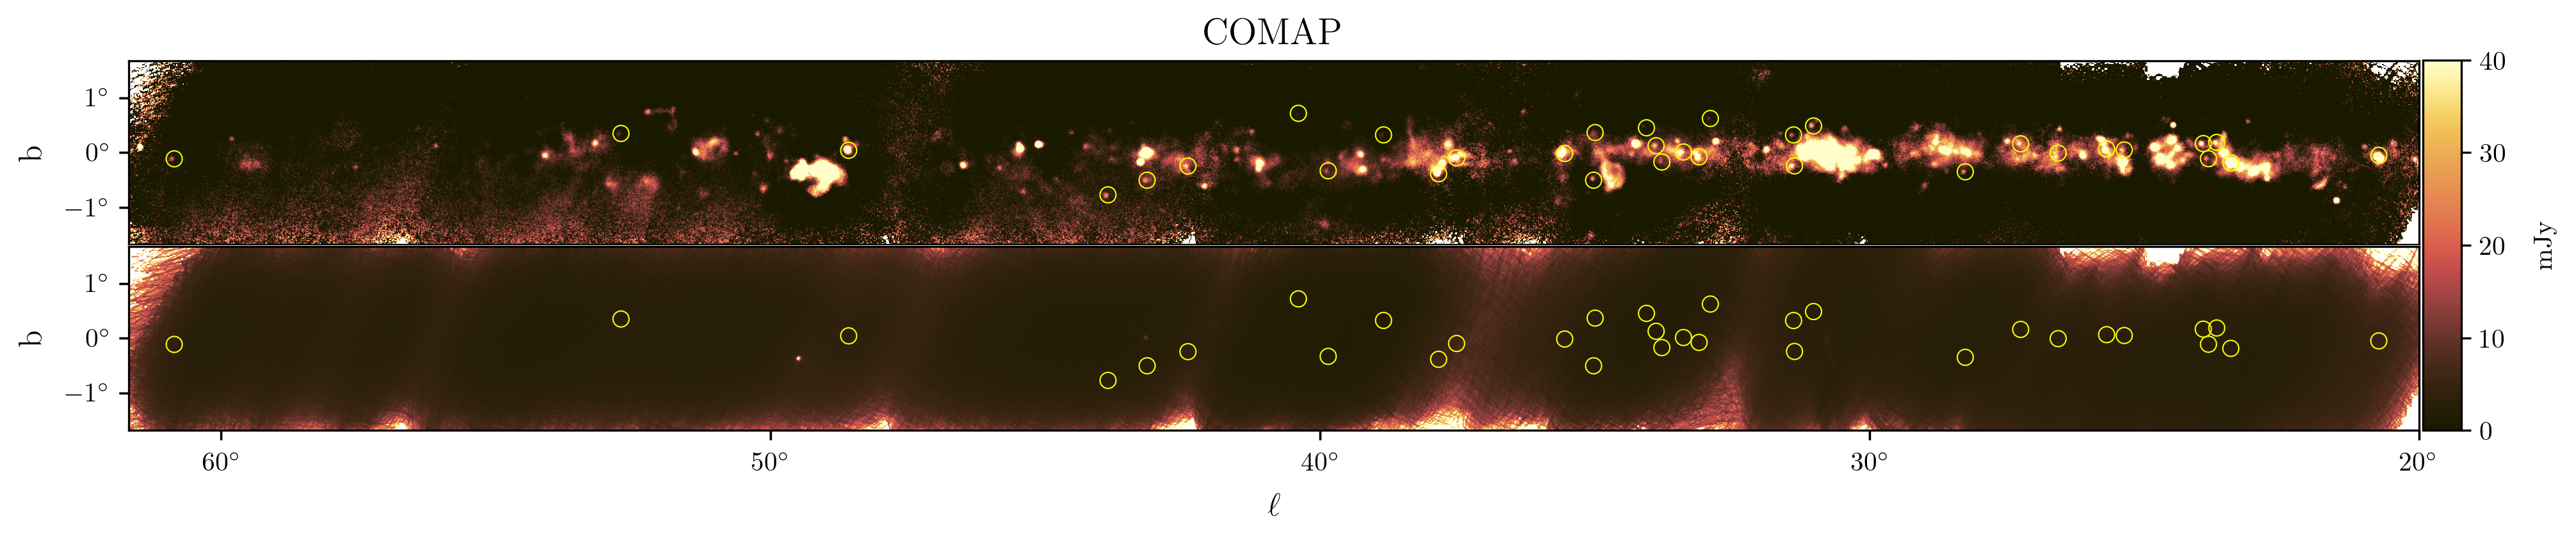

In [13]:
# Detach the Source region
# Specify indices for the desired source
order = 0
start_row = 200
end_row = 400
start_column = 7100
end_column = 9600

x_size = end_column - start_column + 1
y_size = end_row - start_row + 1

wcs = WCS(header)
wcs.wcs.crpix[0] -= start_column
wcs.wcs.crpix[1] -= start_row

# Extract the source
comap_plot = [row[start_column:end_column + 1] for row in comap_27GHz[start_row:end_row + 1]]
comap_noise_plot = [row[start_column:end_column + 1] for row in comap_27GHz_noise[start_row:end_row + 1]]

# Criar um novo colormap baseado no batlowK
cmap_modified = cm.lajolla
cmap_modified.set_bad(color='white')  # Define a cor branca para valores ausentes (NaN)

for i in range(x_size):
    for j in range(y_size):
        if (comap_plot[j][i] == 0):
            comap_plot[j][i] = np.nan

plt.rc('text', usetex=True)
plt.rc('font', family='serif') 

fig, axs = plt.subplots(2, 1, subplot_kw={'projection': wcs}, figsize=(16, 9), dpi=300)
im1 = axs[0].imshow(comap_plot, origin='lower', cmap=cmap_modified, vmin=0, vmax=40)
axs[0].scatter(2* 5401.0 - iso_sources['l_deg'] / 0.0166666 - start_column, 301.0 + iso_sources['b_deg'] / 0.0166666 - start_row,
               color='yellow', marker='o', facecolor='none', linewidths=.5)
axs[0].set_xlabel(' ', fontsize=12)
axs[0].set_ylabel(r'b', fontsize=12)
axs[0].set_title('COMAP', fontsize=14)
axs[0].tick_params(axis='x', labelsize=10, bottom=False, labelbottom=False)
axs[0].tick_params(axis='y', labelsize=10, left=True, right=False)

im2 = axs[1].imshow(comap_noise_plot, origin='lower', cmap=cmap_modified ,vmin=0,vmax=40)
axs[1].scatter(2 * 5401.0 - iso_sources['l_deg'] / 0.0166666 - start_column, 301.0 + iso_sources['b_deg'] / 0.0166666 - start_row, 
               color='yellow', marker='o', facecolor='none', linewidths=.5)
axs[1].set_xlabel(r'$\ell$', fontsize=12)
axs[1].set_ylabel(r'b', fontsize=12)
axs[1].set_title(' ', fontsize=16)
axs[1].tick_params(axis='both', labelsize=12)
axs[1].tick_params(axis='x', labelsize=10, top=False, bottom=True)
axs[1].tick_params(axis='y', labelsize=10, left=True, right=False)

# Adjust the coordinates of the subplots to leave space for the color bar
fig.subplots_adjust(right=0.87, wspace=0.2, hspace=-0.838)

# Add a colorbar
cbar_ax = fig.add_axes([0.8712, 0.388, 0.0125, 0.2143])  
cbar = fig.colorbar(im2, cax=cbar_ax, label='mJy' , orientation='vertical')
cbar.ax.set_ylabel('mJy', rotation=90, labelpad=10) 
plt.savefig('figures/comap_uchii_general.png', dpi=300, facecolor='white', bbox_inches='tight')

In [15]:
index    = []
dindex   = []
flux     = []
dflux    = []
snr      = []
res_mean = []
dres     = []
list_flux_cornish = []
list_dflux_cornish = []
ang_size = []
em       = []
dem      = []
nu_turn  = []
dnu_turn = []

  0%|          | 0/3000 [00:00<?, ?it/s]

100%|██████████| 3000/3000 [00:06<00:00, 485.21it/s]


<Figure size 100x100 with 0 Axes>

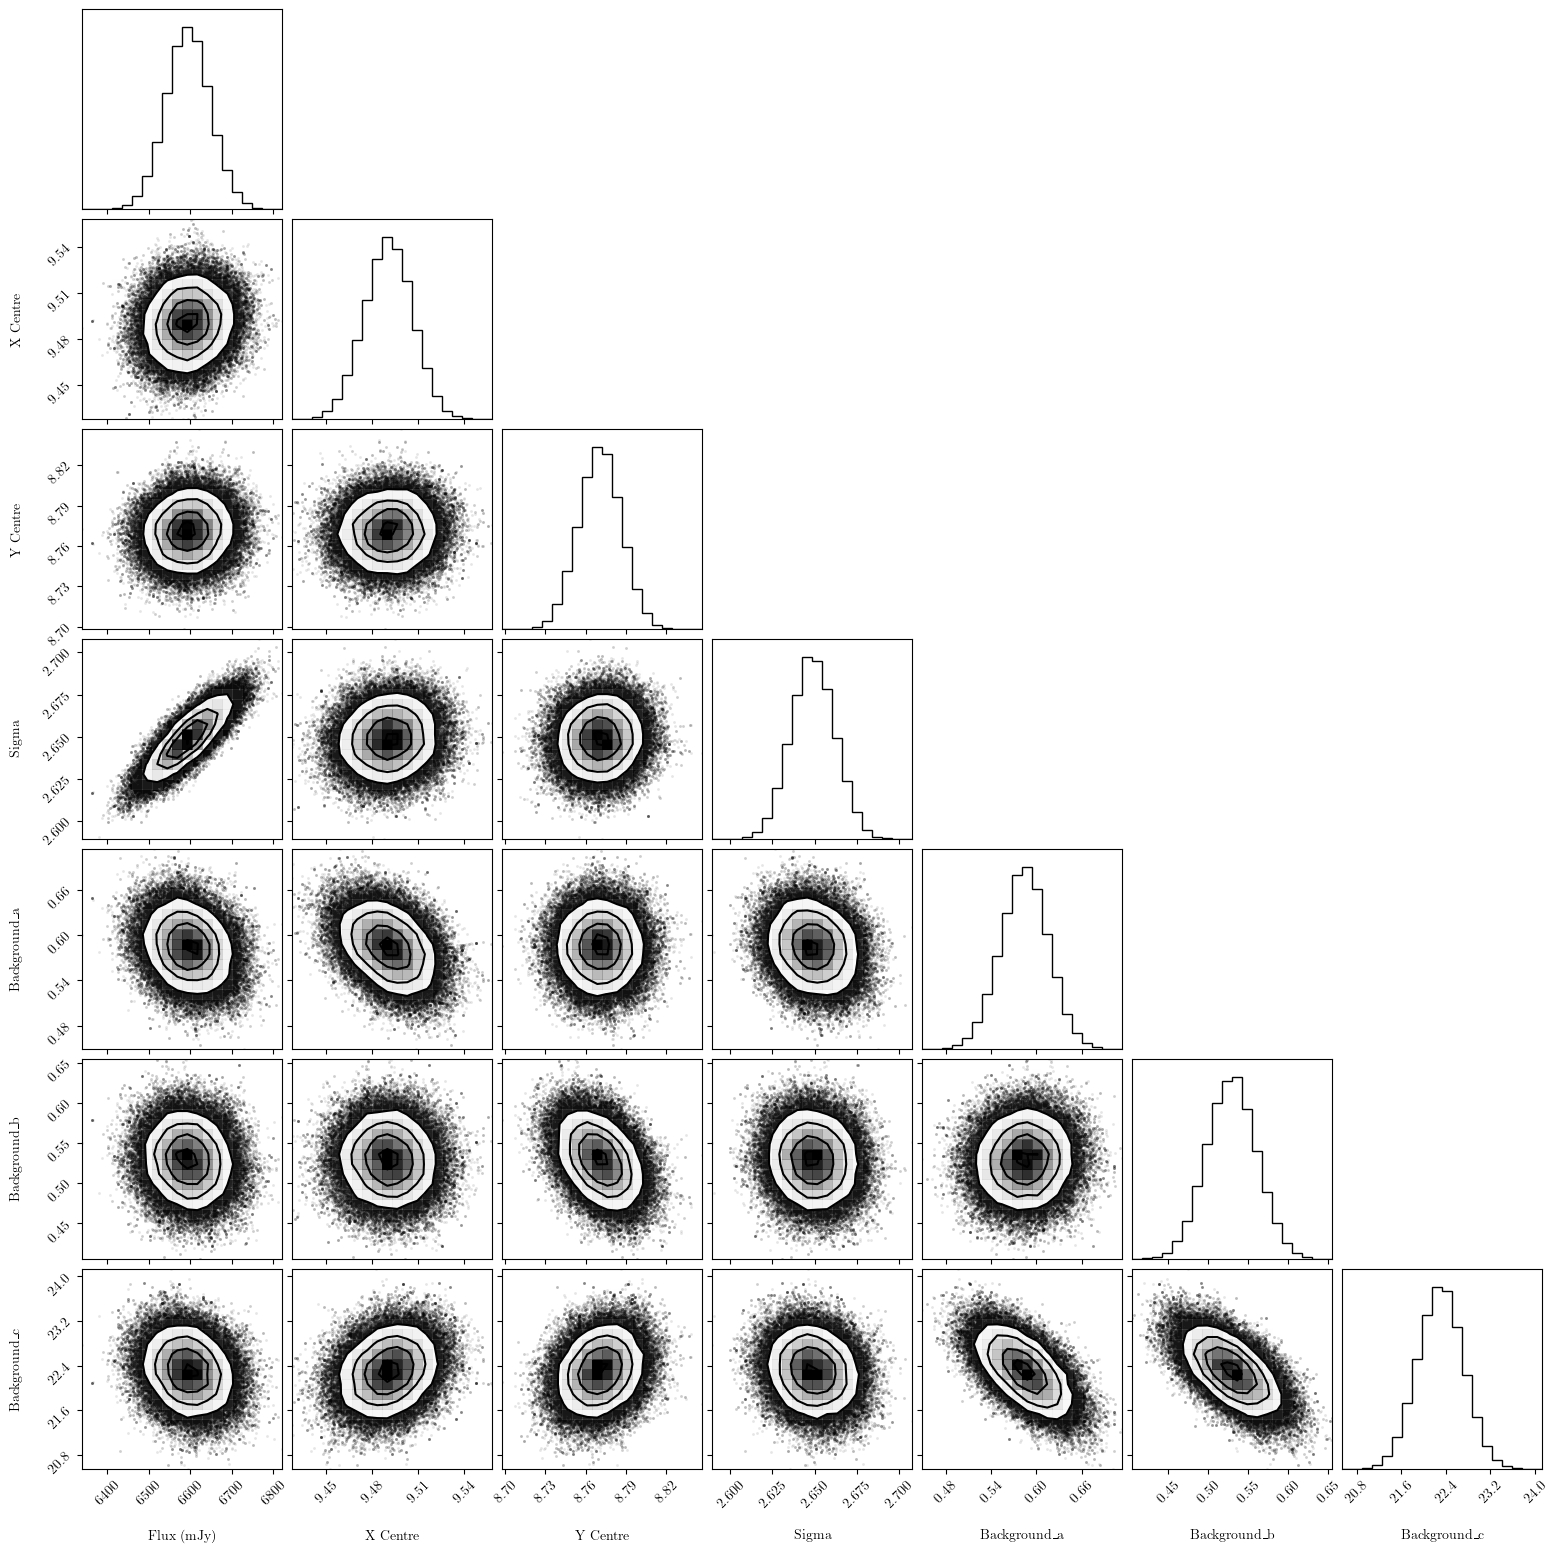

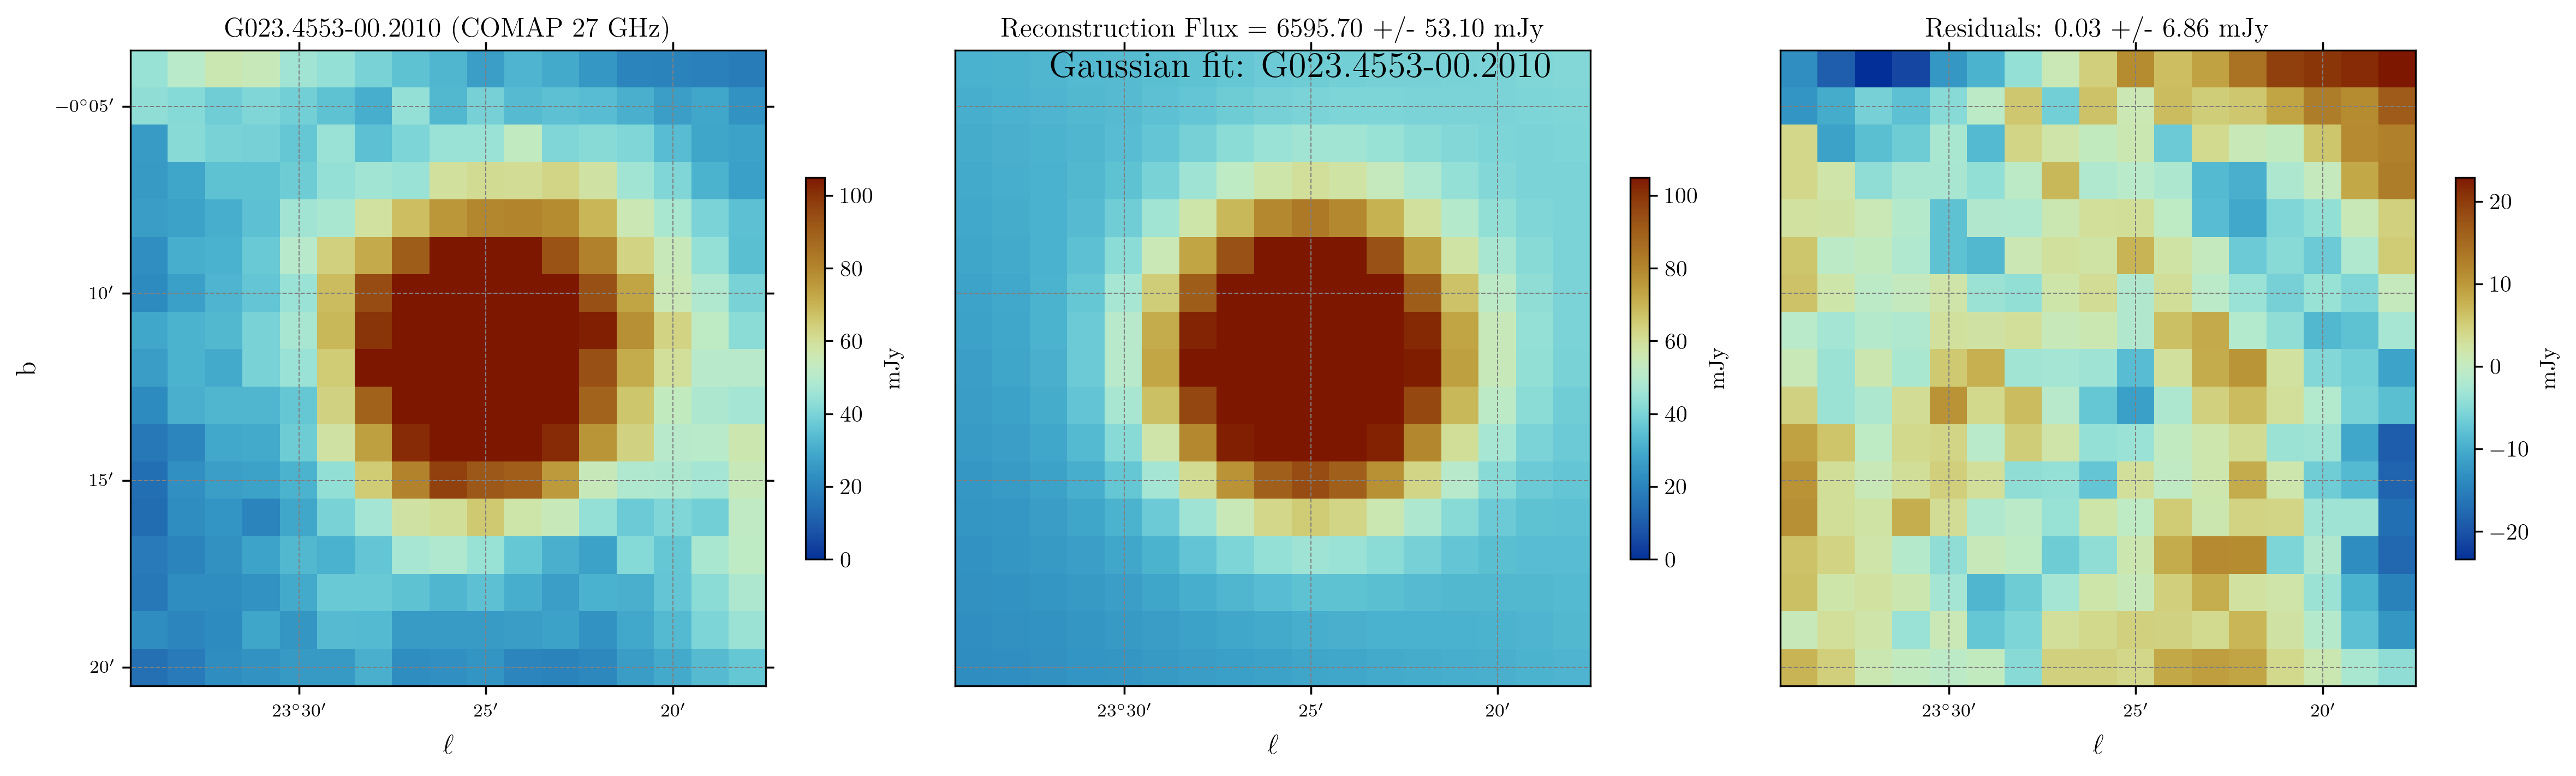

In [21]:
# G023.8618-00.1250 Flux = 39.16 +/-6.29 mJy !!!!!!!!!!!!! This source has a nearby emitting source in CORNISH. Are we only seeing UCHII emission?
# 18:35:13.95	-08:07:23.08
# Detach the Source region
# Specify indices for the desired source
order = 1
box_size = 8
vmax = 105

start_row = int(b_pix[order] - box_size)
end_row = int(b_pix[order] + box_size)
start_column = int(l_pix[order] - box_size)
end_column = int(l_pix[order] + box_size)

x_size = end_column - start_column + 1
y_size = end_row - start_row + 1

initial_parameters = [6500, x_size/2, y_size/2, 3, 0, 0, 0]

x_size = end_column - start_column + 1
y_size = end_row - start_row + 1

wcs = WCS(header)
wcs.wcs.crpix[0] -= start_column
wcs.wcs.crpix[1] -= start_row

# Extract the source
source = [row[start_column:end_column + 1] for row in comap_27GHz[start_row:end_row + 1]]
source_noise = [row[start_column:end_column + 1] for row in comap_27GHz_noise[start_row:end_row + 1]]
source_noise = np.array(source_noise)

# MCMC code
x_space = np.linspace(0,x_size,x_size)
y_space = np.linspace(0,y_size,y_size)
x_mesh, y_mesh = np.meshgrid(x_space, y_space)

error = source_noise

# Define the log-likelihood function 
def ln_likelihood(parameters, x, y, z):
    model = gaussian2D_gradXY(x, y, *parameters)
    residual = (z - model) / error
    return -0.5 * np.sum(residual**2)

# Define the log-prior function
def ln_prior(parameters):
    flux, x_centre, y_centre, sigma, background_a, background_b, background_c = parameters
    if (0 < x_centre < x_size
        and (0 < y_centre < y_size) 
        and (0 < flux)
        and (0 < sigma)):
        return 0.0
    return -np.inf

# Define the log-posterior function
def ln_posterior(parameters, x, y, z):
    prior = ln_prior(parameters)
    if not np.isfinite(prior):
        return -np.inf
    likelihood = ln_likelihood(parameters, x, y, z)
    #print(parameters, prior + likelihood)
    return prior + likelihood

# Update the dimension for MCMC walkers
n_dim = 7  # number of model parameters
n_walkers = 100
n_steps   = 3000

# Update the initial parameters and positions
initial_positions = [initial_parameters + 1e-4 * np.random.randn(n_dim) for _ in range(n_walkers)]

# Update the MCMC sampler
sampler = emcee.EnsembleSampler(n_walkers, n_dim, ln_posterior, args=(x_mesh, y_mesh, source))

# Run the MCMC 
sampler.run_mcmc(initial_positions, n_steps, progress=True)

# Get samples 
samples = sampler.get_chain(discard=1000, flat=True)

# Calculate the mean flux from the samples
mean_flux = samples.mean(axis=0)
mean_std = samples.std(axis=0)

mean_flux_plot = f"{mean_flux[0]:.2f}"
mean_std_plot= f"{mean_std[0]:.2f}"

# Visualize samples using the corner plot
labels = ['Flux (mJy)', 'X Centre', 'Y Centre', 'Sigma', 'Background_a', 'Background_b', 'Background_c']

plt.figure(figsize=(1,1))
fig = corner.corner(samples, labels=labels, smooth=0)
plt.show()

fig, axs = plt.subplots(1, 3, subplot_kw={'projection': wcs}, figsize=(16, 9), dpi=300)
im1 = axs[0].imshow(source, origin='lower', cmap=cm.roma_r,vmin=0,vmax=vmax)
axs[0].set_xlabel(r'$\ell$', fontsize=12)
axs[0].set_ylabel('b', fontsize=12)
axs[0].set_title(source_cornish_names[order] + ' (COMAP 27 GHz)', fontsize=12)
axs[0].tick_params(axis='both', labelsize=8)
axs[0].grid(color='gray', linestyle='--', linewidth=.5)

sim = gaussian2D_gradXY(x_mesh, y_mesh, flux=samples.mean(axis=0)[0], x_centre=samples.mean(axis=0)[1],
                 y_centre=samples.mean(axis=0)[2], sigma=samples.mean(axis=0)[3], background_a=samples.mean(axis=0)[4],
                 background_b=samples.mean(axis=0)[5], background_c=samples.mean(axis=0)[6])

im2 = axs[1].imshow(sim, origin='lower', cmap=cm.roma_r,vmin=0,vmax=vmax)
axs[1].set_xlabel(r'$\ell$', fontsize=12)
axs[1].set_ylabel(' ', fontsize=12)
axs[1].set_title('Reconstruction Flux = ' + str(mean_flux_plot) + ' +/- ' + str(mean_std_plot) + ' mJy', fontsize=12)
axs[1].tick_params(axis='both', labelsize=8)
axs[1].tick_params(axis='y', labelsize=10, left=False, right=False, labelleft=False)
axs[1].grid(color='gray', linestyle='--', linewidth=.5)

im3 = axs[2].imshow((sim - source),  origin='lower', cmap=cm.roma_r)
axs[2].set_xlabel(r'$\ell$', fontsize=12)
axs[2].set_ylabel('b', fontsize=12)
axs[2].set_title('Residuals: ' + str(f"{np.mean(sim - source):.2f}") + ' +/- ' + str(f"{np.std(sim - source):.2f}") +' mJy', fontsize=12)
axs[2].tick_params(axis='both', labelsize=8)
axs[2].tick_params(axis='y', labelsize=10, left=False, right=False, labelleft=False)
axs[2].grid(color='gray', linestyle='--', linewidth=.5)

fig.colorbar(im1, label='mJy', orientation='vertical',shrink=0.295)
fig.colorbar(im2, label='mJy', orientation='vertical',shrink=0.295)
fig.colorbar(im3, label='mJy', orientation='vertical',shrink=0.295)

plt.suptitle('Gaussian fit: ' + source_cornish_names[order], fontsize=16, y=.72)
plt.tight_layout()
plt.savefig('figures/gf_' + source_cornish_names[order] + '.png', dpi=300, facecolor='white', bbox_inches='tight')